# Myanmar Ground Truth Labels — Hex Grid
Extracts Wikipedia territorial control labels at 0.5° grid cell resolution.
Aligns actor names between Wikipedia and UCDP.

**Output:** `data/processed/myanmar_control_labels_hexgrid.csv`
Columns: `cell_id, center_lon, center_lat, date, control_actor, control_broad`

**Prerequisites:**
- SVG snapshots in `data/raw/wikipedia_snapshots/myanmar_YYYY-MM-DD.svg`
- `uv add svglib reportlab rasterio shapely`


In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter
from shapely.geometry import box, Point, mapping
import warnings
warnings.filterwarnings('ignore')

from svglib.svglib import svg2rlg
from reportlab.graphics import renderPM
from PIL import Image
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import rasterize as rio_rasterize

REPO_ROOT     = Path('..').resolve()
SNAPSHOTS_DIR = REPO_ROOT / 'data' / 'raw' / 'wikipedia_snapshots'
PNG_CACHE     = SNAPSHOTS_DIR / 'png_cache'
OUTPUT_CSV    = REPO_ROOT / 'data' / 'processed' / 'myanmar_control_labels_hexgrid.csv'
GRID_GPKG     = REPO_ROOT / 'data' / 'processed' / 'myanmar_grid_05deg.gpkg'

PNG_CACHE.mkdir(parents=True, exist_ok=True)
(REPO_ROOT / 'data' / 'processed').mkdir(parents=True, exist_ok=True)
print("Ready")


Ready


## Step 1 — Build 0.5° grid over Myanmar

PRIO-GRID standard: 0.5° × 0.5° cells (~55km).
We clip to Myanmar's bounding box and keep only cells
that intersect Myanmar's land area.


Full grid: 684 cells
Cells intersecting Myanmar: 320
Saved grid → C:\Users\corne\OneDrive\Nuttige dingen\Verder studeren Spanje\BSE\LEERSTOF\Term3\Thesis\territorial_control_dsdm_master_project\data\processed\myanmar_grid_05deg.gpkg


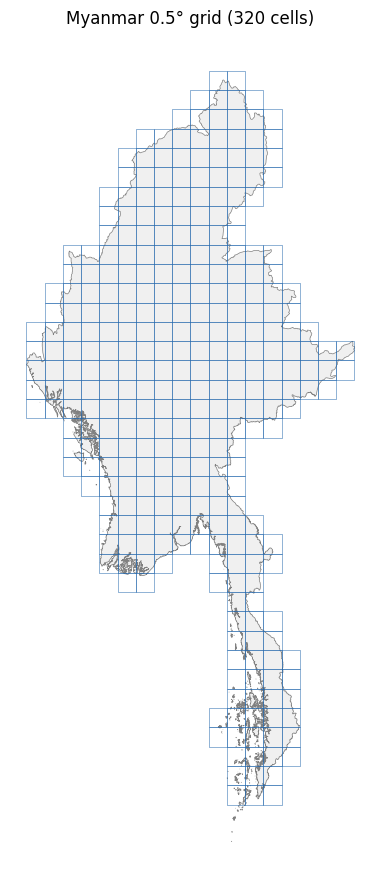

In [2]:
# Myanmar bounding box
MMR_BBOX = (92.17, 9.78, 101.17, 28.55)  # (lon_min, lat_min, lon_max, lat_max)
CELL_SIZE = 0.5  # degrees

# ── Generate grid cells ────────────────────────────────────────────────────────
lon_min, lat_min, lon_max, lat_max = MMR_BBOX

lons = np.arange(lon_min, lon_max, CELL_SIZE)
lats = np.arange(lat_min, lat_max, CELL_SIZE)

cells_geom = []
cell_ids   = []
centers    = []

for i, lon in enumerate(lons):
    for j, lat in enumerate(lats):
        geom = box(lon, lat, lon + CELL_SIZE, lat + CELL_SIZE)
        cell_id = f"MMR_{lon:.1f}_{lat:.1f}"
        cells_geom.append(geom)
        cell_ids.append(cell_id)
        centers.append((lon + CELL_SIZE/2, lat + CELL_SIZE/2))

grid = gpd.GeoDataFrame({
    'cell_id':    cell_ids,
    'center_lon': [c[0] for c in centers],
    'center_lat': [c[1] for c in centers],
}, geometry=cells_geom, crs='EPSG:4326')

print(f"Full grid: {len(grid)} cells")

# ── Clip to Myanmar land area using GADM ──────────────────────────────────────
gadm_path = REPO_ROOT / 'data' / 'raw' / 'gadm' / 'gadm41_MMR.gpkg'
myanmar = gpd.read_file(str(gadm_path), layer='ADM_ADM_0').to_crs('EPSG:4326')
myanmar_union = myanmar.geometry.unary_union

# Keep cells that intersect Myanmar
grid = grid[grid.geometry.intersects(myanmar_union)].reset_index(drop=True)
print(f"Cells intersecting Myanmar: {len(grid)}")

# Save for reuse
grid.to_file(str(GRID_GPKG), driver='GPKG')
print(f"Saved grid → {GRID_GPKG}")

# Plot
fig, ax = plt.subplots(figsize=(6, 9))
myanmar.plot(ax=ax, facecolor='#f0f0f0', edgecolor='grey', linewidth=0.5)
grid.plot(ax=ax, facecolor='none', edgecolor='#2166ac', linewidth=0.5, alpha=0.7)
ax.set_title(f'Myanmar 0.5° grid ({len(grid)} cells)', fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()


## Step 2 — Actor mapping: Wikipedia → UCDP → Broad category

Maps between the different naming conventions so our labels
align with both the Wikipedia map and UCDP actor names.


In [3]:
# ── Wikipedia SVG color → actor name ─────────────────────────────────────────
COLOR_MAP_RGB = {
    # ── Tatmadaw / SAC (salmon-pink tones) ───────────────────────────────────
    (235,192,179): ('Tatmadaw',   'Junta'),
    (235,191,178): ('Tatmadaw',   'Junta'),
    (235,190,178): ('Tatmadaw',   'Junta'),
    (235,192,178): ('Tatmadaw',   'Junta'),
    (207,149,156): ('Tatmadaw',   'Junta'),
    (237,149,149): ('Tatmadaw',   'Junta'),
    (205,124,124): ('Tatmadaw',   'Junta'),
    (245,155,171): ('Tatmadaw',   'Junta'),
    (112, 51, 58): ('Tatmadaw',   'Junta'),
    (234,204,204): ('Tatmadaw',   'Junta'),
    (230,200,200): ('Tatmadaw',   'Junta'),

    # ── Contested ─────────────────────────────────────────────────────────────
    (255,  0,  0): ('Contested',  'Contested'),
    (214, 74, 74): ('Contested',  'Contested'),
    (255,127, 42): ('Contested',  'Contested'),

    # ── PDF / NUG ─────────────────────────────────────────────────────────────
    (202,231,196): ('PDF',        'Resistance'),
    (169,232,155): ('PDF',        'Resistance'),

    # ── KIA ───────────────────────────────────────────────────────────────────
    (204,234,221): ('KIA',        'Resistance'),
    (107,198,129): ('KIA',        'Resistance'),
    ( 35,197,  0): ('KIA',        'Resistance'),
    ( 69,235, 34): ('KIA',        'Resistance'),
    ( 33,143, 59): ('KIA',        'Resistance'),

    # ── KNU / Karen (blues + blue-grey variants) ──────────────────────────────
    (136,192,242): ('KNU',        'Resistance'),
    (198,236,255): ('KNU',        'Resistance'),
    ( 22,119,205): ('KNU',        'Resistance'),
    (132,188,213): ('KNU',        'Resistance'),
    (138,190,214): ('KNU',        'Resistance'),
    (137,190,213): ('KNU',        'Resistance'),
    (142,192,214): ('KNU',        'Resistance'),
    (140,191,214): ('KNU',        'Resistance'),
    (139,191,214): ('KNU',        'Resistance'),

    # ── Arakan Army / ULA (yellows) ───────────────────────────────────────────
    (243,235,165): ('ULA/AA',     'Resistance'),
    (226,226, 97): ('ULA/AA',     'Resistance'),
    (223,202,  8): ('ULA/AA',     'Resistance'),
    (226,226, 29): ('ULA/AA',     'Resistance'),
    (218,209,126): ('ULA/AA',     'Resistance'),
    (250,222,105): ('ULA/AA',     'Resistance'),

    # ── Chin forces ───────────────────────────────────────────────────────────
    ( 77,182,137): ('CNF',        'Resistance'),
    (193,231, 69): ('CNF',        'Resistance'),

    # ── MNDAA ─────────────────────────────────────────────────────────────────
    (229, 96, 68): ('MNDAA',      'Resistance'),

    # ── NMSP / Mon ────────────────────────────────────────────────────────────
    (134,222,204): ('NMSP',       'Resistance'),
    (  0,192,192): ('NMSP',       'Resistance'),
    (150,239,239): ('NMSP',       'Resistance'),

    # ── PNLO / Pa-O (purples) ─────────────────────────────────────────────────
    (166,144,223): ('PNLO',       'Resistance'),
    (165,152,215): ('PNLO',       'Resistance'),
    (197,189,199): ('PNLO',       'Resistance'),
    (216,171,231): ('PNLO',       'Resistance'),

    # ── KNPP / Karenni ────────────────────────────────────────────────────────
    (232,153,183): ('KNPP',       'Resistance'),
    (242,137,227): ('KNPP',       'Resistance'),

    # ── RCSS / SSA-South ──────────────────────────────────────────────────────
    (184,184,171): ('RCSS/SSA-S', 'Autonomous'),
    (187,187,168): ('RCSS/SSA-S', 'Autonomous'),

    # ── SSPP / SSA-North (greys) ──────────────────────────────────────────────
    (141,149,145): ('SSPP/SSA-N', 'Autonomous'),
    (224,224,224): ('SSPP/SSA-N', 'Autonomous'),
    (193,193,193): ('SSPP/SSA-N', 'Autonomous'),
    (214,220,223): ('SSPP/SSA-N', 'Autonomous'),
    (216,221,223): ('SSPP/SSA-N', 'Autonomous'),
    (218,218,218): ('SSPP/SSA-N', 'Autonomous'),
    (173,204,218): ('SSPP/SSA-N', 'Autonomous'),

    # ── UWSA ──────────────────────────────────────────────────────────────────
    (204,215,210): ('UWSA',       'Other'),
    (183,157,157): ('UWSA',       'Other'),
}

print(f"Color map: {len(COLOR_MAP_RGB)} colors")
cats = Counter(v[1] for v in COLOR_MAP_RGB.values())
for cat, n in sorted(cats.items()):
    print(f"  {cat:12s}: {n} colors")


Color map: 59 colors
  Autonomous  : 9 colors
  Contested   : 3 colors
  Junta       : 11 colors
  Other       : 2 colors
  Resistance  : 34 colors


## Step 3 — SVG rendering and color sampling

In [4]:
MMR = {
    'lon_min': 92.17, 'lon_max': 101.17,
    'lat_min':  9.78, 'lat_max':  28.55,
}

def render_svg(svg_path, png_path):
    if png_path.exists(): return
    drawing = svg2rlg(str(svg_path))
    renderPM.drawToFile(drawing, str(png_path), fmt='PNG', dpi=72, bg=0xFFFFFF)

def get_transform(img_array):
    h, w = img_array.shape[:2]
    return from_bounds(
        MMR['lon_min'], MMR['lat_min'],
        MMR['lon_max'], MMR['lat_max'],
        width=w, height=h
    )

def closest_color(rgb, tolerance=30):
    r, g, b = int(rgb[0]), int(rgb[1]), int(rgb[2])
    if r > 240 and g > 240 and b > 240: return None, None  # white
    if r <  20 and g <  20 and b <  20: return None, None  # black
    if abs(r-g) < 10 and abs(g-b) < 10 and r > 220: return None, None  # light grey border

    best_label, best_cat, best_d = 'Unknown', 'Unknown', float('inf')
    for ref, (label, cat) in COLOR_MAP_RGB.items():
        d = ((r-ref[0])**2 + (g-ref[1])**2 + (b-ref[2])**2) ** 0.5
        if d < best_d:
            best_d, best_label, best_cat = d, label, cat
    return (best_label, best_cat) if best_d <= tolerance else ('Unknown', 'Unknown')

def majority_color_in_cell(img_array, polygon, transform):
    img_h, img_w = img_array.shape[:2]
    mask = rio_rasterize(
        [(mapping(polygon), 1)],
        out_shape=(img_h, img_w),
        transform=transform,
        fill=0, dtype='uint8'
    )
    ys, xs = np.where(mask == 1)
    if len(ys) == 0: return None

    ys = np.clip(ys, 0, img_h - 1)
    xs = np.clip(xs, 0, img_w - 1)
    pixels = img_array[ys, xs]

    valid = []
    for p in pixels:
        r, g, b = int(p[0]), int(p[1]), int(p[2])
        if r > 240 and g > 240 and b > 240: continue
        if r <  20 and g <  20 and b <  20: continue
        if abs(r-g) < 10 and abs(g-b) < 10 and r > 220: continue
        valid.append((r, g, b))

    if not valid: return None
    return Counter(valid).most_common(1)[0][0]

print("Functions defined")


Functions defined


## Step 4 — Process all snapshots → grid-level labels

In [5]:
EXPECTED_DATES = [
    '2023-12-30',
    '2024-01-09',
    '2024-04-04',
    '2024-08-09',
    '2024-11-10',
    '2025-01-05',
    '2025-04-04',
]

print("SVG snapshot status:")
available = []
for date in EXPECTED_DATES:
    p = SNAPSHOTS_DIR / f'myanmar_{date}.svg'
    if p.exists():
        print(f"  ✓  myanmar_{date}.svg")
        available.append((date, p))
    else:
        print(f"  ✗  myanmar_{date}.svg  ← save from Wikimedia file history")

print(f"\nReady: {len(available)} / {len(EXPECTED_DATES)}")


SVG snapshot status:
  ✓  myanmar_2023-12-30.svg
  ✓  myanmar_2024-01-09.svg
  ✓  myanmar_2024-04-04.svg
  ✓  myanmar_2024-08-09.svg
  ✓  myanmar_2024-11-10.svg
  ✓  myanmar_2025-01-05.svg
  ✓  myanmar_2025-04-04.svg

Ready: 7 / 7


In [6]:
all_records = []

for date, svg_path in available:
    png_path = PNG_CACHE / f'myanmar_{date}.png'
    print(f"{date}: rendering...", end=' ', flush=True)
    render_svg(svg_path, png_path)
    img_array  = np.array(Image.open(png_path).convert('RGB'))
    transform  = get_transform(img_array)
    print(f"({img_array.shape[1]}x{img_array.shape[0]}). Sampling {len(grid)} cells...",
          end=' ', flush=True)

    n_unknown = 0
    for _, row in grid.iterrows():
        rgb = majority_color_in_cell(img_array, row.geometry, transform)

        if rgb is None:
            actor, cat = 'Unknown', 'Unknown'
        else:
            actor, cat = closest_color(rgb)
            if actor == 'Unknown':
                n_unknown += 1

        all_records.append({
            'date':          date,
            'cell_id':       row['cell_id'],
            'center_lon':    row['center_lon'],
            'center_lat':    row['center_lat'],
            'control_actor': actor,
            'control_broad': cat,
        })

    cats = Counter(r['control_broad'] for r in all_records if r['date'] == date)
    print({k:v for k,v in sorted(cats.items(), key=lambda x: str(x[0]))},
          f"| {n_unknown} unmapped")

labels_df = pd.DataFrame(all_records)
labels_df.to_csv(str(OUTPUT_CSV), index=False)
print(f"\n✓ Saved {len(labels_df):,} records → {OUTPUT_CSV}")
print(labels_df['control_broad'].value_counts())


2023-12-30: rendering... (921x1502). Sampling 320 cells... {'Autonomous': 25, 'Contested': 1, 'Junta': 96, 'Other': 3, 'Resistance': 150, 'Unknown': 45} | 33 unmapped
2024-01-09: rendering... (921x1502). Sampling 320 cells... {'Autonomous': 28, 'Contested': 3, 'Junta': 89, 'Other': 3, 'Resistance': 152, 'Unknown': 45} | 33 unmapped
2024-04-04: rendering... (921x1502). Sampling 320 cells... {'Autonomous': 28, 'Contested': 4, 'Junta': 90, 'Other': 3, 'Resistance': 151, 'Unknown': 44} | 32 unmapped
2024-08-09: rendering... (921x1502). Sampling 320 cells... {'Autonomous': 28, 'Contested': 4, 'Junta': 88, 'Other': 3, 'Resistance': 152, 'Unknown': 45} | 33 unmapped
2024-11-10: rendering... (921x1502). Sampling 320 cells... {'Autonomous': 31, 'Contested': 4, 'Junta': 84, 'Other': 3, 'Resistance': 153, 'Unknown': 45} | 33 unmapped
2025-01-05: rendering... (921x1502). Sampling 320 cells... {'Autonomous': 34, 'Contested': 5, 'Junta': 79, 'Other': 3, 'Resistance': 154, 'Unknown': 45} | 33 unmappe

## Step 5 — Visualize

Unknown cells in 2023-12-30: 45

Top colors found in unknown cells (excluding white/black/border grey):

Hex        RGB                     Count  Closest match
-----------------------------------------------------------------
#646464    (100, 100, 100)         2,977  Tatmadaw (Junta) d=66
#ebc0b3    (235, 192, 179)           397  Tatmadaw (Junta) d=0
#ff7f2a    (255, 127, 42)            137  Contested (Contested) d=0
#ed9595    (237, 149, 149)           130  Tatmadaw (Junta) d=0
#88c0f2    (136, 192, 242)           120  KNU (Resistance) d=0
#656565    (101, 101, 101)           116  Tatmadaw (Junta) d=67
#666666    (102, 102, 102)            76  Tatmadaw (Junta) d=68
#cae7c4    (202, 231, 196)            69  PDF (Resistance) d=0
#fade69    (250, 222, 105)            63  ULA/AA (Resistance) d=0
#6a6a6a    (106, 106, 106)            53  SSPP/SSA-N (Autonomous) d=68
#8abed6    (138, 190, 214)            46  KNU (Resistance) d=0
#676767    (103, 103, 103)            45  Tatmadaw (Junta) d=

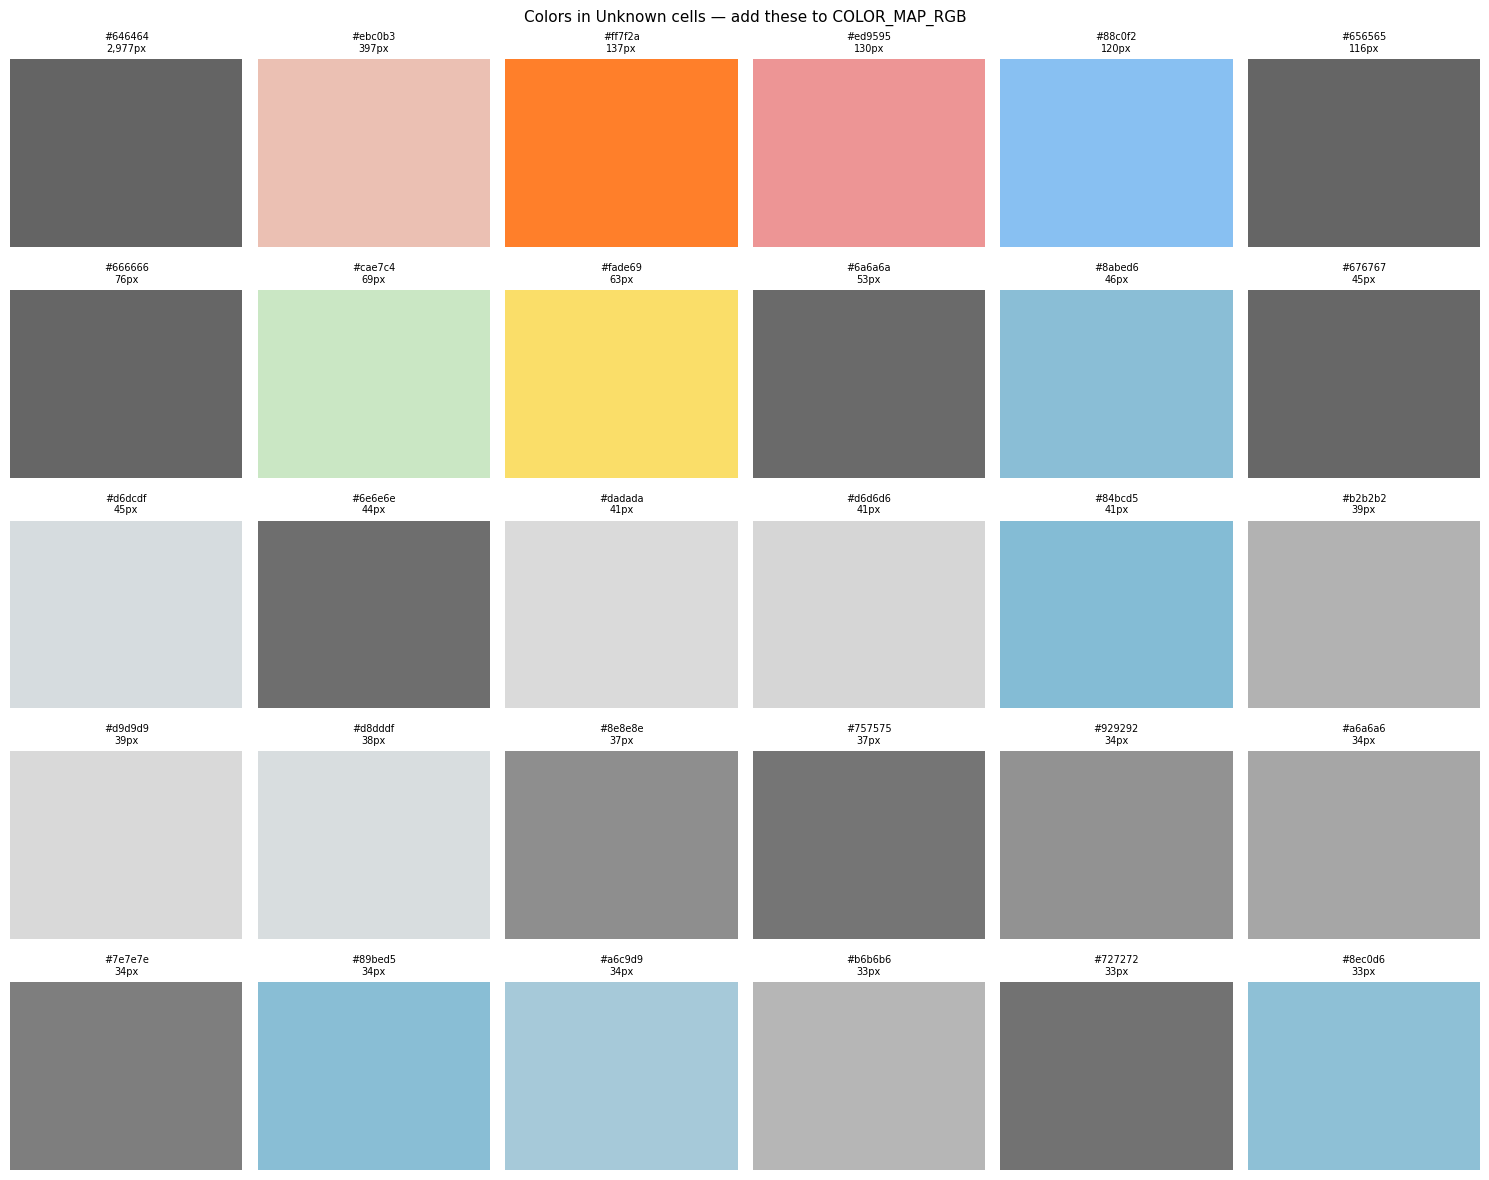

In [7]:
# ── DIAGNOSTIC: find colors in Unknown cells ──────────────────────────────────
# Run this to identify which colors are missing from the color map

from PIL import Image
from rasterio.features import rasterize as rio_rasterize
from shapely.geometry import mapping
from collections import Counter
import numpy as np

# Use the 2023-12-30 snapshot (most unknowns)
diag_date = '2023-12-30'
png_path  = PNG_CACHE / f'myanmar_{diag_date}.png'
img_array = np.array(Image.open(str(png_path)).convert('RGB'))
transform = get_transform(img_array)
img_h, img_w = img_array.shape[:2]

# Get unknown cells for this date
unknown_cells = labels_df[
    (labels_df['date'] == diag_date) &
    (labels_df['control_broad'] == 'Unknown')
]['cell_id'].tolist()

print(f"Unknown cells in {diag_date}: {len(unknown_cells)}")
print("\nTop colors found in unknown cells (excluding white/black/border grey):\n")

all_unknown_colors = []

for cell_id in unknown_cells:
    row = grid[grid['cell_id'] == cell_id].iloc[0]
    mask = rio_rasterize(
        [(mapping(row.geometry), 1)],
        out_shape=(img_h, img_w),
        transform=transform,
        fill=0, dtype='uint8'
    )
    ys, xs = np.where(mask == 1)
    if len(ys) == 0: continue
    ys = np.clip(ys, 0, img_h-1)
    xs = np.clip(xs, 0, img_w-1)
    pixels = img_array[ys, xs]
    for p in pixels:
        r, g, b = int(p[0]), int(p[1]), int(p[2])
        if r > 240 and g > 240 and b > 240: continue
        if r <  20 and g <  20 and b <  20: continue
        if abs(r-g) < 10 and abs(g-b) < 10 and r > 220: continue
        all_unknown_colors.append((r, g, b))

top_colors = Counter(all_unknown_colors).most_common(30)

print(f"{'Hex':10s} {'RGB':20s} {'Count':>8s}  Closest match")
print("-" * 65)
for rgb, count in top_colors:
    hex_c = f'#{rgb[0]:02x}{rgb[1]:02x}{rgb[2]:02x}'
    # Find nearest existing color
    best_d, best_label = float('inf'), '?'
    for ref, (label, cat) in COLOR_MAP_RGB.items():
        d = ((rgb[0]-ref[0])**2 + (rgb[1]-ref[1])**2 + (rgb[2]-ref[2])**2) ** 0.5
        if d < best_d:
            best_d, best_label = d, f'{label} ({cat}) d={d:.0f}'
    print(f"{hex_c:10s} {str(rgb):20s} {count:>8,}  {best_label}")

# Also show color swatches
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(5, 6, figsize=(15, 12))
axes = axes.flatten()
for i, (rgb, count) in enumerate(top_colors[:30]):
    ax = axes[i]
    ax.add_patch(plt.Rectangle((0,0),1,1, facecolor=[c/255 for c in rgb]))
    hex_c = f'#{rgb[0]:02x}{rgb[1]:02x}{rgb[2]:02x}'
    ax.set_title(f'{hex_c}\n{count:,}px', fontsize=7)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.suptitle('Colors in Unknown cells — add these to COLOR_MAP_RGB', fontsize=11)
plt.tight_layout()
plt.show()


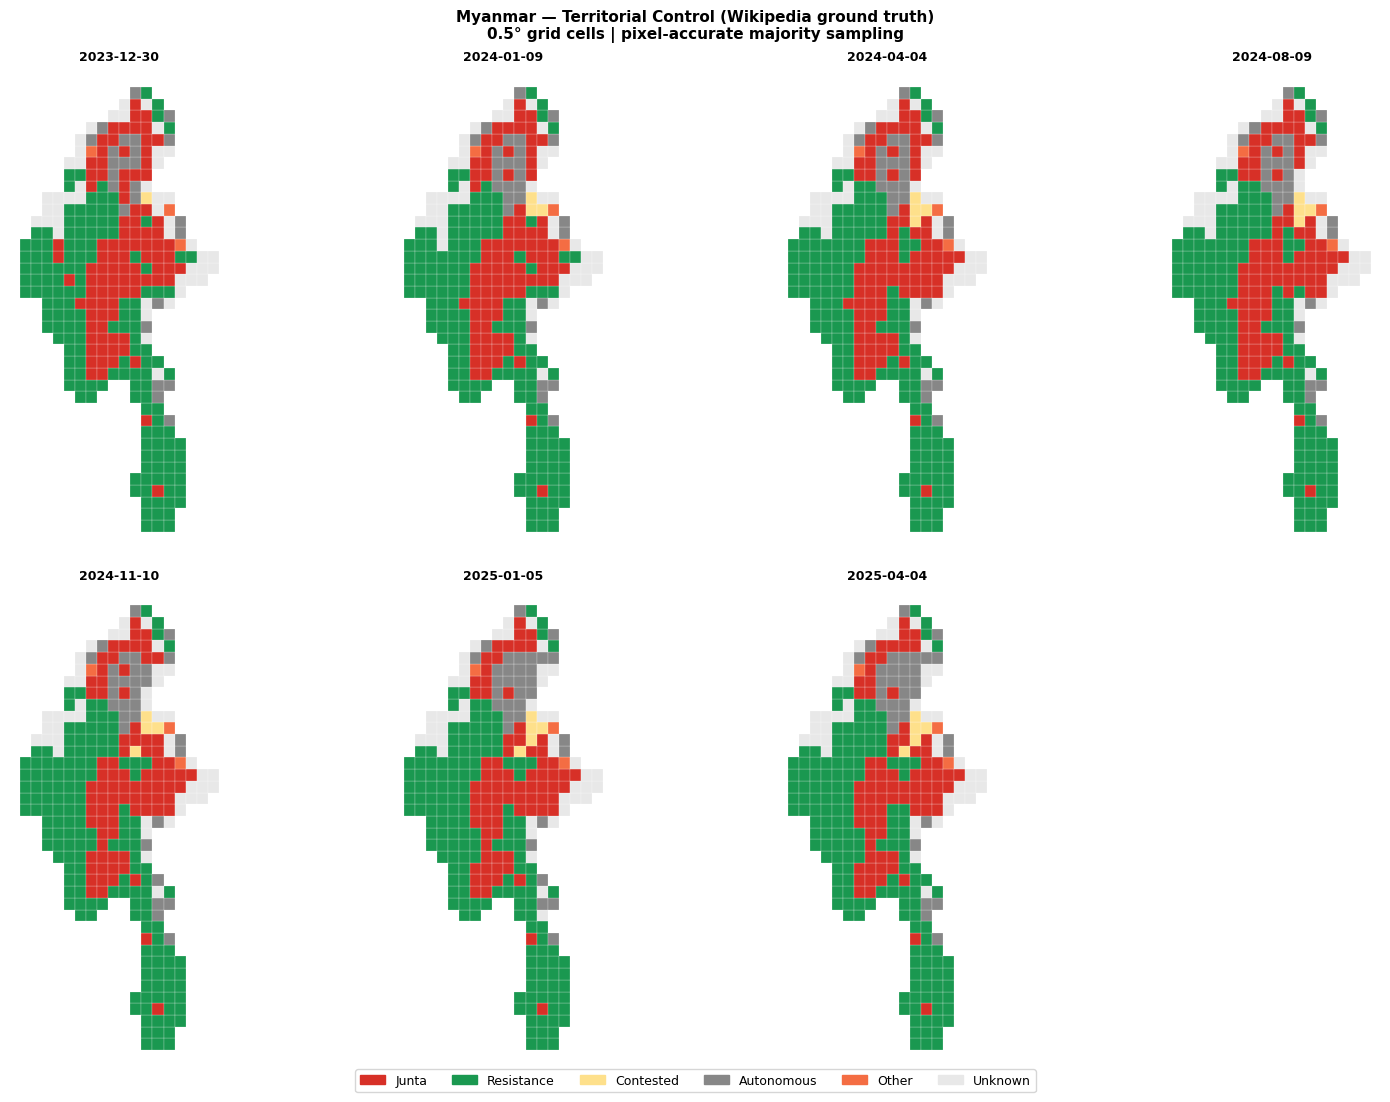

Saved → C:\Users\corne\OneDrive\Nuttige dingen\Verder studeren Spanje\BSE\LEERSTOF\Term3\Thesis\territorial_control_dsdm_master_project\reports\figures\myanmar_wiki_labels_hexgrid.png


In [8]:
BROAD_COLORS = {
    'Junta':      '#d73027',
    'Resistance': '#1a9850',
    'Contested':  '#fee08b',
    'Autonomous': '#878787',
    'Other':      '#f46d43',
    'Unknown':    '#e8e8e8',
}

if 'labels_df' in dir() and len(labels_df) > 0:
    dates = sorted(labels_df['date'].unique())
    ncols = min(4, len(dates))
    nrows = -(-len(dates) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*5.5))
    axes = np.array(axes).flatten()

    for i, date in enumerate(dates):
        ax     = axes[i]
        d_data = labels_df[labels_df['date'] == date][['cell_id','control_broad']]
        merged = grid.merge(d_data, on='cell_id', how='left')
        merged['control_broad'] = merged['control_broad'].fillna('Unknown')
        merged['color']         = merged['control_broad'].map(BROAD_COLORS).fillna('#e8e8e8')
        merged.plot(color=merged['color'], ax=ax,
                    edgecolor='white', linewidth=0.15)
        ax.set_title(date, fontsize=9, fontweight='bold', pad=3)
        ax.set_axis_off()

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    patches = [mpatches.Patch(color=v, label=k) for k,v in BROAD_COLORS.items()]
    fig.legend(handles=patches, loc='lower center', ncol=6,
               fontsize=9, bbox_to_anchor=(0.5, -0.01))
    fig.suptitle('Myanmar — Territorial Control (Wikipedia ground truth)\n'
                 '0.5° grid cells | pixel-accurate majority sampling',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    out = REPO_ROOT / 'reports' / 'figures' / 'myanmar_wiki_labels_hexgrid.png'
    plt.savefig(str(out), dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved → {out}")


## Step 6 — Sanity checks

In [9]:
if 'labels_df' in dir() and len(labels_df) > 0:
    # Key known facts to validate:
    # 1. Naypyidaw area (~96.1E, 19.8N) — always Junta
    # 2. Kachin State (~97.5E, 25.5N) — always KIA/Resistance
    # 3. Lashio (~97.75E, 22.9N) — Junta before Aug 2024, Resistance after
    # 4. Rakhine/Ann (~93.7E, 19.7N) — Arakan Army / Resistance

    checks = [
        ('Naypyidaw',  96.1, 19.8,  'Always Junta'),
        ('Kachin',     97.5, 25.5,  'Always KIA/Resistance'),
        ('Lashio',     97.75, 22.9, 'Junta→Resistance Aug 2024'),
        ('Rakhine/Ann',93.7, 19.7,  'Arakan Army/Resistance'),
        ('UWSA/Wa',    99.5, 22.5,  'Autonomous throughout'),
    ]

    for name, lon, lat in [(c[0],c[1],c[2]) for c in checks]:
        # Find nearest cell
        dists = ((labels_df['center_lon'] - lon)**2 +
                 (labels_df['center_lat'] - lat)**2) ** 0.5
        nearest_cell = labels_df.loc[dists.idxmin(), 'cell_id']
        sub = labels_df[labels_df['cell_id'] == nearest_cell]
        note = [c[3] for c in checks if c[0] == name][0]
        print(f"--- {name} cell={nearest_cell} ({note}) ---")
        print(sub[['date','control_actor','control_broad']].to_string(index=False))
        print()


--- Naypyidaw cell=MMR_95.7_19.8 (Always Junta) ---
      date control_actor control_broad
2023-12-30      Tatmadaw         Junta
2024-01-09      Tatmadaw         Junta
2024-04-04      Tatmadaw         Junta
2024-08-09      Tatmadaw         Junta
2024-11-10      Tatmadaw         Junta
2025-01-05      Tatmadaw         Junta
2025-04-04      Tatmadaw         Junta

--- Kachin cell=MMR_97.2_25.3 (Always KIA/Resistance) ---
      date control_actor control_broad
2023-12-30    SSPP/SSA-N    Autonomous
2024-01-09    SSPP/SSA-N    Autonomous
2024-04-04    SSPP/SSA-N    Autonomous
2024-08-09    SSPP/SSA-N    Autonomous
2024-11-10    SSPP/SSA-N    Autonomous
2025-01-05    SSPP/SSA-N    Autonomous
2025-04-04    SSPP/SSA-N    Autonomous

--- Lashio cell=MMR_97.7_22.8 (Junta→Resistance Aug 2024) ---
      date control_actor control_broad
2023-12-30           PDF    Resistance
2024-01-09           PDF    Resistance
2024-04-04     Contested     Contested
2024-08-09     Contested     Contested
2024-11

## Step 7 — UCDP actor alignment check

In [10]:
# Load UCDP Myanmar data and verify actor mapping coverage
ucdp_path = REPO_ROOT / 'data' / 'raw' / 'ucdp'
ucdp_files = list(ucdp_path.glob('*.csv'))
print(f"UCDP files: {[f.name for f in ucdp_files]}")

if ucdp_files:
    ucdp = pd.read_csv(str(ucdp_files[0]))
    ucdp_mmr = ucdp[
        (ucdp.get('country', ucdp.get('country_id', pd.Series())).astype(str).str.contains('Myanmar|Burma', na=False)) &
        (ucdp.get('type_of_violence', pd.Series()) == 1)
    ] if 'country' in ucdp.columns or 'country_id' in ucdp.columns else ucdp

    all_actors = pd.concat([
        ucdp_mmr.get('side_a', pd.Series()),
        ucdp_mmr.get('side_b', pd.Series())
    ]).dropna().unique()

    print(f"\nAll unique actors in UCDP Myanmar ({len(all_actors)}):")
    mapped   = [a for a in all_actors if a in UCDP_ACTOR_MAP]
    unmapped = [a for a in all_actors if a not in UCDP_ACTOR_MAP]

    print(f"\nMapped ({len(mapped)}):")
    for a in sorted(mapped):
        print(f"  {a:40s} → {UCDP_ACTOR_MAP[a]}")

    print(f"\nUnmapped ({len(unmapped)}) — need to add to UCDP_ACTOR_MAP:")
    for a in sorted(unmapped):
        print(f"  {a}")


UCDP files: ['GEDEvent_v25_1.csv']

All unique actors in UCDP Myanmar (22):


NameError: name 'UCDP_ACTOR_MAP' is not defined

In [11]:
# ── Add missing UCDP actors ───────────────────────────────────────────────────
UCDP_ACTOR_MAP.update({
    'BMA':        'Other',   # Border Guard Force / Buddhist militia
    "God's Army": 'Other',   # Small Karen splinter group (historical)
    'RSO':        'Other',   # Rohingya Solidarity Organisation
    'MDA - LM':   'Other',   # Mon splinter group
    'Buddhists (Myanmar)': 'Other',  # communal violence
    'Muslims (Myanmar)':   'Other',  # communal violence
})
print(f"UCDP actor map now covers {len(UCDP_ACTOR_MAP)} actors")
print("All actors mapped:", all(a in UCDP_ACTOR_MAP
      for a in ['BMA', "God's Army", 'RSO']))


NameError: name 'UCDP_ACTOR_MAP' is not defined